## Athens UF PM campaign at NOA Jan-Feb 2025

In [16]:
# Install packages
!pip install pandas openpyxl matplotlib

  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 6.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 6.2 MB/s eta 0:00:01
   ----------------- ---------------------- 3.7/8.3 MB 6.1 MB/s eta 0:00:01
   ----------------------- ---------------- 5.0/8.3 MB 6.2 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 6.3 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 6.1 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp314-cp314-win_


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# Install libraries
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm

In [3]:
# Define working directories
wdir = Path("C:/Users/GeorgiaRg/Documents/Athens2025/Python_analysis")
os.chdir(wdir) # Change directory
output_dir = "C:/Users/GeorgiaRg/Documents/Athens2025/Python_analysis/output" # Define the name or path of your output folder
os.makedirs(output_dir, exist_ok=True) # exist_ok=True prevents an error if you run this cell multiple times

## Import NOA data

In [4]:
df_noa_1 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/UF PM Campaign (Athens-Thissio 2025).xlsx", sheet_name="hourly data")
df_noa_2 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/UF PM Campaign (Athens-Thissio 2025).xlsx", sheet_name="BC")
df_noa_3 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/Th_ACSM_PMF_Jan_Feb25.xlsx", sheet_name="ACSM_raw")
df_noa_4 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/Th_ACSM_PMF_Jan_Feb25.xlsx", sheet_name="PMF_raw")
#ptrms noa
#df_noa_5 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/NOA data/Thissio_ambient_11sec_clean_winter_campaign.xlsx", sheet_name="Thissio_ambient_11sec")

# Prep function for data that is ALREADY hourly
def prep_hourly_data(df, time_col_name):
    if time_col_name not in df.columns:
        raise ValueError(f"Column '{time_col_name}' not found. Please check your Excel headers.")
    df = df.copy()
    df['Datetime'] = pd.to_datetime(df[time_col_name]).dt.round('h')
    df = df.set_index('Datetime')
    df_numeric = df.select_dtypes(include='number')

    return df_numeric

# Prep function for RAW data that needs averaging
def make_hourly_averages(df, time_col_name):
    if time_col_name not in df.columns:
        raise ValueError(f"Column '{time_col_name}' not found. Please check your Excel headers.")
    df = df.copy()
    df['Datetime'] = pd.to_datetime(df[time_col_name])

    df = df.set_index('Datetime')
    df_numeric = df.select_dtypes(include='number')
    df_hourly = df_numeric.resample('h').mean()

    return df_hourly

# These are already hourly, so we just prep them
hourly_noa_1 = prep_hourly_data(df_noa_1, time_col_name="DateTime")
hourly_noa_2 = prep_hourly_data(df_noa_2, time_col_name="DateTime")
# These are raw, so we average them
hourly_noa_3 = make_hourly_averages(df_noa_3, time_col_name="DateTime")
hourly_noa_4 = make_hourly_averages(df_noa_4, time_col_name="DateTime")

df_noa_all = pd.concat([hourly_noa_1, hourly_noa_2, hourly_noa_3, hourly_noa_4], axis=1, sort=False) # Merge them all together
df_noa_all = df_noa_all.reset_index() # Clean up: Move Datetime from the index back to a normal column
df_noa_all['Datetime'] = df_noa_all['Datetime'].dt.round('h') # Round the Datetime column to the nearest exact hour
df_noa_all = df_noa_all.groupby('Datetime').mean().reset_index() # Group the data by this perfectly rounded hour and combine the rows

In [5]:
df_noa_all # Display the final dataframe

,Datetime,O3 (μg/m3),CO (mg/m3),CO2 (mg/m3),CH4 (mg/m3),NO (μg/m3),NO2 (μg/m3),PM2.5 (μg/m3) _ GRIMM,PM2.5 (μg/m3) _ Beta 5014i,Air Temperature (°C),...,NO3_prcor_CE (μgm-3),SO4_prcor_CE (μgm-3),NH4_prcor_CE (μgm-3),Cl_prcor_CE (μgm-3),HOA (μgm-3),COA (μgm-3),BBOA (μgm-3),LOOOA (μgm-3),MOOOA (μgm-3),OOA (μgm-3)
0,2025-01-20 00:00:00,10.589460,0.848844,841.027612,1.411365,3.506980,52.415249,41.071667,34.345500,9.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-20 01:00:00,11.221875,0.771616,841.329009,1.410319,2.481738,50.800565,33.593333,35.005833,9.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-20 02:00:00,34.788810,0.479883,818.951527,1.392298,0.656546,33.121576,22.811667,25.262833,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-20 03:00:00,35.615073,0.416095,821.641006,1.417040,0.311750,28.133168,20.848333,20.133833,8.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-20 04:00:00,40.030007,0.340457,816.457439,1.396274,0.311750,29.320520,12.846667,16.415500,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,2025-02-21 19:00:00,75.985227,0.303786,806.931473,1.354379,0.311750,17.577653,18.650000,15.393500,5.1,...,0.639171,2.881984,0.788876,0.108893,0.612658,1.405380,0.900534,2.425590,1.506257,3.931847
788,2025-02-21 20:00:00,77.633430,0.302497,806.619900,1.353687,0.311750,17.851707,18.750000,15.843167,4.7,...,0.607114,3.219981,1.001194,0.163411,0.836702,2.225156,0.954701,2.648562,1.785074,4.433636
789,2025-02-21 21:00:00,77.888125,0.303669,805.189148,1.354049,0.311750,17.552797,18.978333,16.798667,4.6,...,0.495719,2.281856,0.512058,0.098816,1.253524,2.027012,1.045286,2.328956,1.211315,3.540270
790,2025-02-21 22:00:00,80.615955,0.299266,800.840863,1.351632,0.311750,15.483695,16.350000,17.496667,4.8,...,0.481993,2.024620,0.415472,0.087619,0.653359,1.093623,0.954549,1.904947,0.987239,2.892186


In [6]:
#Change O3, NO, NO2 to ppb and CO, CO2 and CH4 to ppm
df_noa_all_original = df_noa_all #keep original dataframe with gases in mg/m3 and μg/m3

# At 25°C and 1 atm, Vm = 24.45 L/mol.
Vm = 24.45
# Molecular Weights (g/mol) for each gas
mw = {
    'O3': 48.00,
    'NO': 30.01,
    'NO2': 46.01,
    'CO': 28.01,
    'CO2': 44.01,
    'CH4': 16.04
}

# Convert µg/m3 to ppb using Formula: ppb = (µg/m3) * (Vm / MW)
df_noa_all['O3 (μg/m3)'] = df_noa_all['O3 (μg/m3)'] * (Vm / mw['O3'])
df_noa_all['NO (μg/m3)'] = df_noa_all['NO (μg/m3)'] * (Vm / mw['NO'])
df_noa_all['NO2 (μg/m3)'] = df_noa_all['NO2 (μg/m3)'] * (Vm / mw['NO2'])

# Convert mg/m3 to ppm using Formula: ppm = (mg/m3) * (Vm / MW)
df_noa_all['CO (mg/m3)'] = df_noa_all['CO (mg/m3)'] * (Vm / mw['CO'])
df_noa_all['CO2 (mg/m3)'] = df_noa_all['CO2 (mg/m3)'] * (Vm / mw['CO2'])
df_noa_all['CH4 (mg/m3)'] = df_noa_all['CH4 (mg/m3)'] * (Vm / mw['CH4'])

# Rename the columns to reflect the new units
df_noa_all = df_noa_all.rename(columns={
    'O3 (μg/m3)': 'O3 (ppb)',
    'NO (μg/m3)': 'NO (ppb)',
    'NO2 (μg/m3)': 'NO2 (ppb)',
    'CO (mg/m3)': 'CO (ppm)',
    'CO2 (mg/m3)': 'CO2 (ppm)',
    'CH4 (mg/m3)': 'CH4 (ppm)'
})

df_noa_all

,Datetime,O3 (ppb),CO (ppm),CO2 (ppm),CH4 (ppm),NO (ppb),NO2 (ppb),PM2.5 (μg/m3) _ GRIMM,PM2.5 (μg/m3) _ Beta 5014i,Air Temperature (°C),...,NO3_prcor_CE (μgm-3),SO4_prcor_CE (μgm-3),NH4_prcor_CE (μgm-3),Cl_prcor_CE (μgm-3),HOA (μgm-3),COA (μgm-3),BBOA (μgm-3),LOOOA (μgm-3),MOOOA (μgm-3),OOA (μgm-3)
0,2025-01-20 00:00:00,5.394006,0.740958,467.237562,2.151364,2.857236,27.853789,41.071667,34.345500,9.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-20 01:00:00,5.716143,0.673546,467.405005,2.149769,2.021942,26.995736,33.593333,35.005833,9.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-20 02:00:00,17.720550,0.418891,454.973070,2.122300,0.534906,17.601011,22.811667,25.262833,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-20 03:00:00,18.141428,0.363210,456.467225,2.160014,0.253992,14.950140,20.848333,20.133833,8.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-20 04:00:00,20.390285,0.297186,453.587466,2.128360,0.253992,15.581107,12.846667,16.415500,8.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
787,2025-02-21 19:00:00,38.704975,0.265176,448.295263,2.064498,0.253992,9.340874,18.650000,15.393500,5.1,...,0.639171,2.881984,0.788876,0.108893,0.612658,1.405380,0.900534,2.425590,1.506257,3.931847
788,2025-02-21 20:00:00,39.544528,0.264050,448.122166,2.063445,0.253992,9.486508,18.750000,15.843167,4.7,...,0.607114,3.219981,1.001194,0.163411,0.836702,2.225156,0.954701,2.648562,1.785074,4.433636
789,2025-02-21 21:00:00,39.674264,0.265074,447.327304,2.063996,0.253992,9.327666,18.978333,16.798667,4.6,...,0.495719,2.281856,0.512058,0.098816,1.253524,2.027012,1.045286,2.328956,1.211315,3.540270
790,2025-02-21 22:00:00,41.063752,0.261230,444.911590,2.060311,0.253992,8.228132,16.350000,17.496667,4.8,...,0.481993,2.024620,0.415472,0.087619,0.653359,1.093623,0.954549,1.904947,0.987239,2.892186


## Import our data

In [7]:
df_so2 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SO2/SO2_hourly.xlsx", sheet_name="SO2")
df_so2

,date,SO2
0,2025-01-21 13:00:00,1.584460
1,2025-01-21 14:00:00,1.028468
2,2025-01-21 15:00:00,0.863088
3,2025-01-21 16:00:00,0.905154
4,2025-01-21 17:00:00,0.948995
...,...,...
712,2025-02-20 05:00:00,0.170343
713,2025-02-20 06:00:00,0.201643
714,2025-02-20 07:00:00,0.214137
715,2025-02-20 08:00:00,0.216168


In [12]:
#sp2xr, measuring BC PM0.1, 1h averaged and dilution corrected
df_sp2_all = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SP2/data_for_processing/hourly_rBC.xlsx", sheet_name="Sheet 1")
df_sp2 = df_sp2_all[['date', 'DILUTION_corr_Incand.Mass.Conc.μg.m3.']].rename(columns={'DILUTION_corr_Incand.Mass.Conc.μg.m3.': 'bc_pm0.1'})

df_sp2

,date,bc_pm0.1
0,2025-01-23 11:00:00,0.084106
1,2025-01-23 12:00:00,0.031685
2,2025-01-23 13:00:00,0.026074
3,2025-01-23 14:00:00,0.028166
4,2025-01-23 15:00:00,0.048985
...,...,...
690,2025-02-21 05:00:00,0.018451
691,2025-02-21 06:00:00,0.042793
692,2025-02-21 07:00:00,0.069698
693,2025-02-21 08:00:00,0.063997


In [ ]:
# SMPSs and CPC50
df_smps_van_dm = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPS3034_dM")
df_smps_van_dmdlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPS3034_dMdlogDp")
df_smps_van_dndlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPS3034_dNdlogDp")
df_smps_noa_dm = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPSregular_dM")
df_smps_noa_dmdlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPSregular_dMdlogDp")
df_smps_noa_dndlogdp = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="SMPSregular_dNdlogDp")
df_cpc50 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/SMPSs/SMPSs.xlsx", sheet_name="CPC50")

In [ ]:
#AMS - PM0.1 [in the van, after the AAC, 3min samples]
df_ams_species = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/AMS/Preliminary_timeseries.xlsx", sheet_name="species_forR_neg")
df_ams_factors = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/AMS/Preliminary_timeseries.xlsx", sheet_name="factors_forR")

In [13]:
#Xact - PM0.1
df_xact_corr = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Processed_data_Athens.xlsx", sheet_name="corrected")  #dilution and blank corrected [based on 2 field blank measurements, n=1]
#df_xact_diagnostics = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Processed_data_Athens.xlsx", sheet_name="diagnostics")
#df_xact_qa = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Processed_data_Athens.xlsx", sheet_name="QAs")

In [14]:
# Our PM2.5 Thermo monitor that was in the Van
data_dir = Path(r"C:/Users/GeorgiaRg/Documents/Athens2025/PM2.5 monitor_van")
dfs = []
for file_path in data_dir.glob("*.dat"):
    df = pd.read_csv(file_path, sep=r'\s+', comment=';')
    dfs.append(df)
df_pm25 = pd.concat(dfs, ignore_index=True)
df_pm25['Datetime'] = pd.to_datetime(df_pm25['Date'] + ' ' + df_pm25['Time'], format='%m-%d-%y %H:%M')
df_pm25 = df_pm25.drop_duplicates(subset=['Datetime'], keep='first')
df_pm25 = df_pm25.sort_values(by='Datetime').reset_index(drop=True)
df_pm25 = df_pm25.drop(columns=['Date', 'Time'])
df_pm25 = df_pm25[['Datetime', 'pm']]  #keep only datetime and pm2.5 values
df_pm25['pm'] = pd.to_numeric(df_pm25['pm'], errors='coerce')
df_pm25_clean = df_pm25
df_pm25_clean['pm'] = df_pm25['pm'].clip(lower=0)  #replace negative values with 0

df_pm25_clean_hourly = df_pm25_clean.resample('h', on='Datetime').mean()
df_pm25_clean_hourly = df_pm25_clean_hourly.reset_index()
#output_file = data_dir / "PM25_Hourly_Averages.xlsx"     #for excel file output of the hourly pm2.5
#df_pm25_clean_hourly.to_excel(output_file, index=False)

df_pm25_clean_hourly

,Datetime,pm
0,2025-01-09 14:00:00,0.000000
1,2025-01-09 15:00:00,0.022761
2,2025-01-09 16:00:00,0.668468
3,2025-01-09 17:00:00,NaN
4,2025-01-09 18:00:00,NaN
...,...,...
1023,2025-02-21 05:00:00,7.405101
1024,2025-02-21 06:00:00,11.482947
1025,2025-02-21 07:00:00,10.001822
1026,2025-02-21 08:00:00,9.734248


## PM2.5 Metals Demokritos

In [15]:
#PM2.5- HVS - quartz filters -WDXRF analysis
df_metals_pm25 = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Metals from Demokritos/PM2.5_Metals_WD-XRF.xlsx", sheet_name="concentrations")
df_metals_pm25_LOD = pd.read_excel(r"C:/Users/GeorgiaRg/Documents/Athens2025/Xact/Metals from Demokritos/PM2.5_Metals_WD-XRF.xlsx", sheet_name="LOD")

## Pseudo 3D size distributions

C:\Users\GeorgiaRg\AppData\Local\Temp\ipykernel_4736\3286945905.py:39: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(x, y, z,


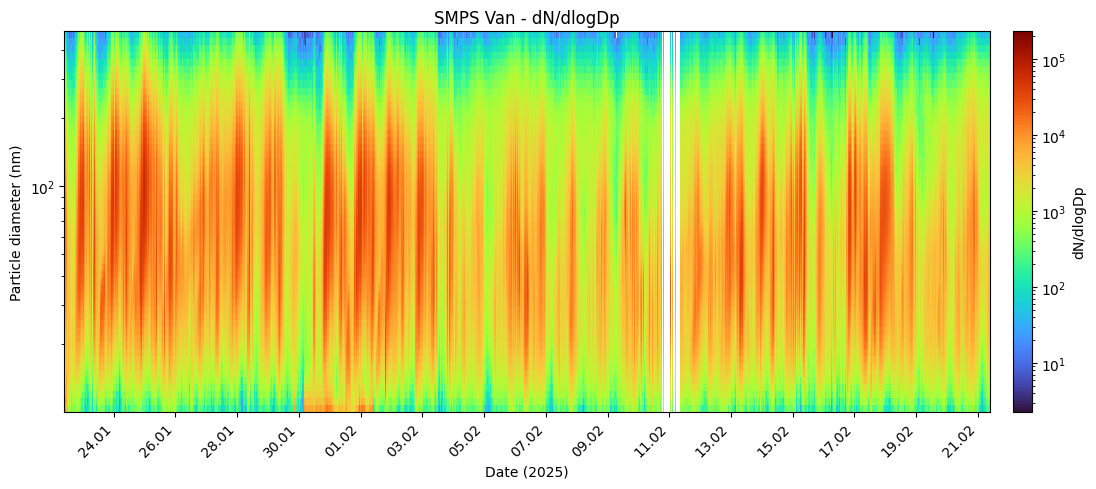

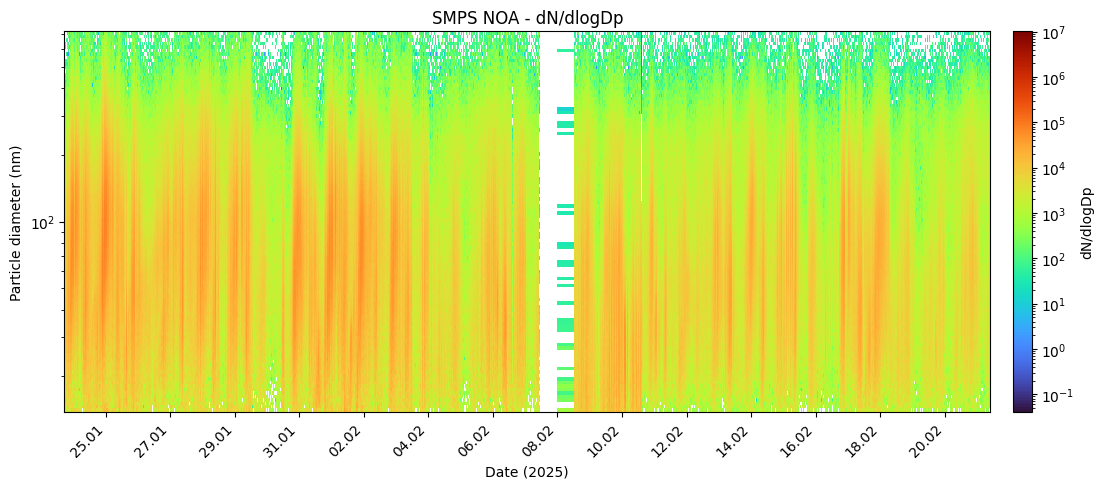

C:\Users\GeorgiaRg\AppData\Local\Temp\ipykernel_4736\3286945905.py:39: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(x, y, z,


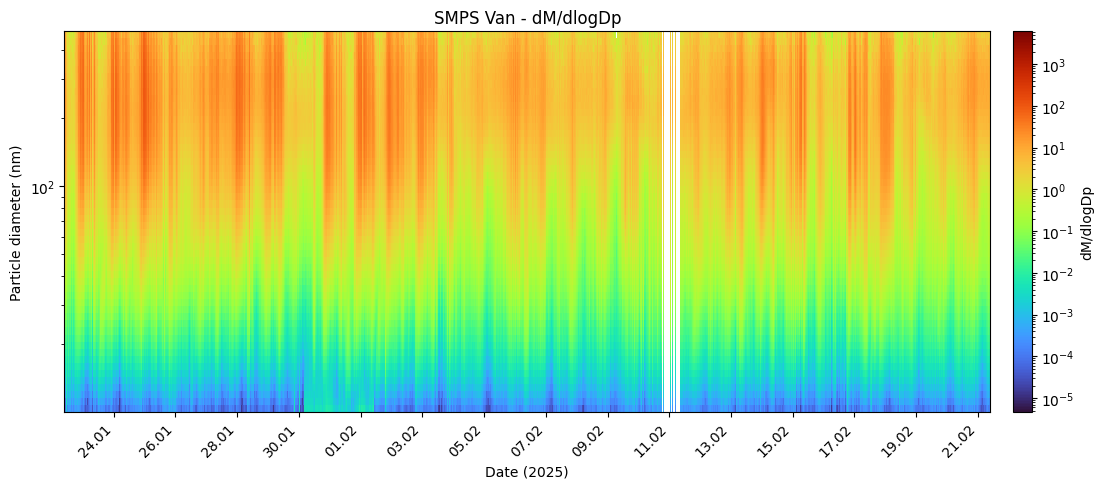

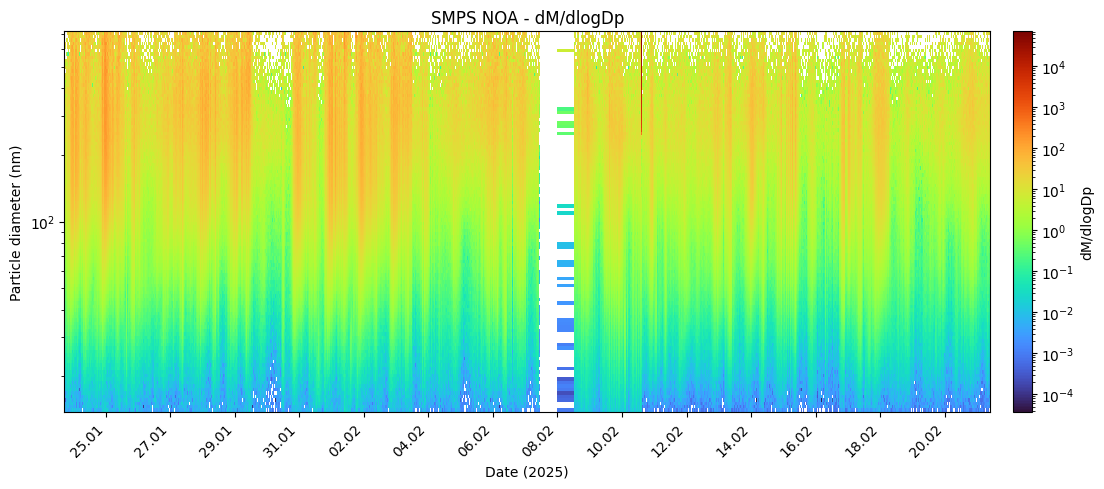

In [28]:
def generate_smps_contour(df, title, z_label="Concentration"):
    df_clean = df.copy()
    df_clean['DateTime'] = pd.to_datetime(df_clean['DateTime'])
    df_clean.set_index('DateTime', inplace=True)

    size_cols = [] # Filter columns: Keep only the numeric particle size columns
    for col in df_clean.columns:
        try:
            float(col)  # Keep if the column name is a number (diameter)
            size_cols.append(col)
        except ValueError:
            pass        # Ignore if it's text (e.g., 'Lower Size', 'Sample #')

    size_cols = sorted(size_cols, key=float) # Force the columns to sort numerically
    df_sizes = df_clean[size_cols] # Extract X (time), Y (diameters), and Z (concentrations)
    x = df_sizes.index
    y = np.array(size_cols, dtype=float)
    z = df_sizes.values.astype(float).T # Transpose Z so rows align with Y (diameters) and columns align with X (time)
    z[z <= 0] = np.nan # LogNorm cannot handle zeros or negative values, replace them with NaNs

    fig, ax = plt.subplots(figsize=(12, 5))
    mesh = ax.pcolormesh(x, y, z, norm=LogNorm(), cmap='turbo', shading='auto')
    ax.set_yscale('log') # Set Y-axis to logarithmic scale
    ax.set_ylabel('Particle diameter (nm)')
    ax.set_xlabel('Date (2025)')
    ax.set_title(title)
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2)) # Set tick marks every 2 days
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
    fig.autofmt_xdate(rotation=45, ha='right') # Rotate the dates slightly so they are easier to read
    cbar = fig.colorbar(mesh, ax=ax, pad=0.02) # Add the colorbar
    cbar.set_label(z_label)

    plt.tight_layout()
    plt.show()

# Plot dNdlogDp data
generate_smps_contour(df_smps_van_dndlogdp, title="SMPS Van - dN/dlogDp", z_label="dN/dlogDp")
generate_smps_contour(df_smps_noa_dndlogdp, title="SMPS NOA - dN/dlogDp", z_label="dN/dlogDp")

# Plot dMdlogDp data
generate_smps_contour(df_smps_van_dmdlogdp, title="SMPS Van - dM/dlogDp", z_label="dM/dlogDp")
generate_smps_contour(df_smps_noa_dmdlogdp, title="SMPS NOA - dM/dlogDp", z_label="dM/dlogDp")